In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from decimal import Decimal
from papermodels.paper.pdf import load_pdf_annotations
from papermodels.datatypes.geometry_graph import GeometryGraph
from papermodels.datatypes.joist_models import (
    JoistArrayModel, 
    CollectorTribModel
)

In [37]:
%matplotlib inline

## 1. Create the graph

In [38]:
graph = GeometryGraph.from_pdf_file("collector_extents.pdf", scale=Decimal(1 / 72 * 4), do_not_process=False)
graph.assign_collector_behaviour(CollectorTribModel)
les = graph.create_loaded_elements()

# New! (v0.11.0)

You can now draw "extent lines" for your collector (joist) members in your annotation drawing. 

> To make an extent line, you must create a new legend entry for your extent lines. You can do this by creating a new linestyle (maybe something that does not visually clutter the drawing, like light grey or black) and in its text box write: `Type: Extent Line`).

The extent line dramatically reduces the amount of time spent drawing annotations because you no longer need to draw a joist annotation for every support condition. When you draw the extent line, `papermodels` will "look" at the area covered by the extent line and create the individual joist prototypes for you for each support condition for you.

> **Note:** There are different extent line behaviours for `CollectorTribModel` and `JoistArrayModel`. For the `JoistArrayModel` it simply creates the joist arrays as per usual but it will cover the whole spread of the extent line now and each joist will determine which support elements it intersects. For the `CollectorTribModel`, collector prototypes will be created for each unique support condition (just like you would have drawn by hand previously) within the extent area.

## Extent limitations

* If you are using `CollectorTribModel`, you still must have only uniform loads within each support area.
* When using `CollectorTribModel`, only orthogonal framing can be used (in other words, an orthogonal framing condition will be _assumed_ by `papermodels`).
* Do not use an extent line to span "jogs" in the exterior framing ("exterior framing" means the first support and last support of a collector member). Ensure that the outer supports are in a straight run even if they are composed of a combination of beams, columns, and walls.

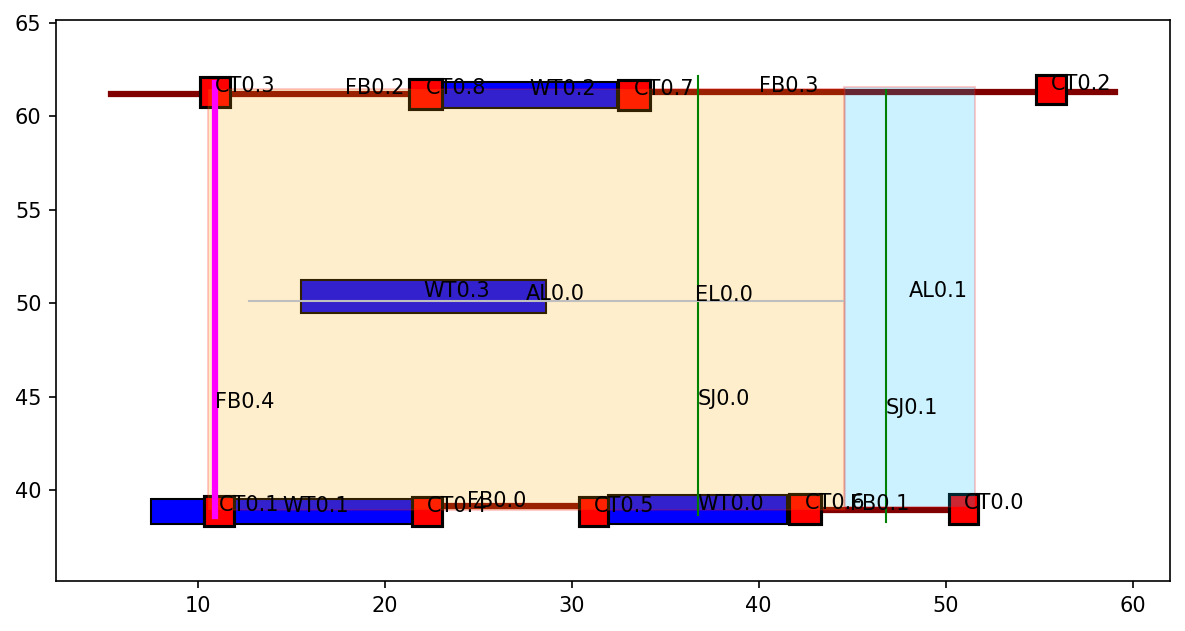

In [39]:
# See how WT0.3 does not have a joist prototype through it? papermodels will "find" the locations of 
# intermediate supports and ensure that there are joist prototypes that intersect it at all required
# locations (a required location is a region with a unique support condition).

# Note, the .plot_annotations() method does not currenly show submembers that are created as part
# of the assigned collector behaviour.

graph.plot_annotations(0)

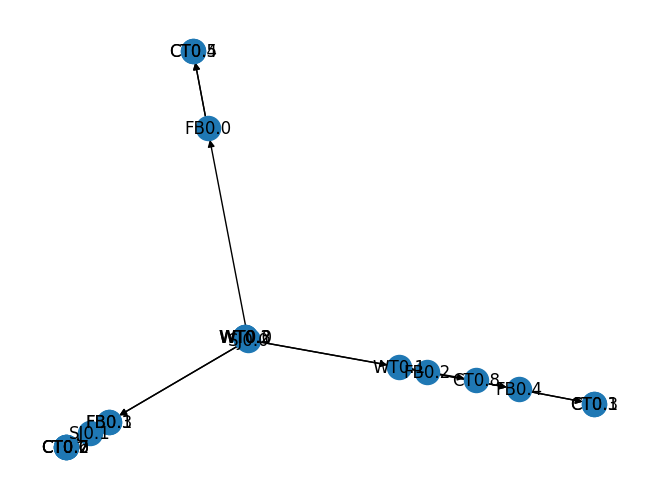

In [40]:
# Note: Currently, the connectivity graph does not show "submembers".
# But it does show all supporting elements within the extent area that
# will eventually be supporting one or more submembers.

graph.plot_connectivity()

In [41]:
# We can inspect the submembers of 'SJ0.0' and see which supports they have
# You can see that the first steel joist ("SJ0.0-0") has only WT0.1 and FB0.2 as suppports...
les['SJ0.0-0'].model()

{'element_attributes': {'tag': 'SJ0.0-0',
  'length': 11.277,
  'orientation': 'horizontal',
  'vert_correspondent_below': [],
  'vert_correspondent_above': [],
  'horz_intersects_above': [],
  'horz_intersects_below': ['WT0.1', 'FB0.2'],
  'user_defined': {}},
 'element_geometry': {'geometry': 'LINESTRING (6.788 18.568, 6.788 29.845)',
  'supports': [{'location': 0.087, 'fixity': 'pin'},
   {'location': 10.8, 'fixity': 'roller'}]},
 'loads': {'point_loads': [],
  'distributed_loads': [{'transfer_source': '',
    'transfer_reaction_index': '',
    'occupancy': 'residential',
    'load_components': [],
    'applied_area': 14.261,
    'start_loc': 0.135,
    'start_magnitude': 0.094,
    'end_loc': 10.8,
    'end_magnitude': 0.094}]}}

In [45]:
# ... but you can see that "SJ0.0-1" also has WT0.3 as an intermediate support
les['SJ0.0-1'].model()

{'element_attributes': {'tag': 'SJ0.0-1',
  'length': 11.277,
  'orientation': 'horizontal',
  'vert_correspondent_below': [],
  'vert_correspondent_above': [],
  'horz_intersects_above': [],
  'horz_intersects_below': ['WT0.1', 'WT0.3', 'FB0.2'],
  'user_defined': {}},
 'element_geometry': {'geometry': 'LINESTRING (8.888 18.568, 8.888 29.845)',
  'supports': [{'location': 0.087, 'fixity': 'pin'},
   {'location': 5.609, 'fixity': 'roller'},
   {'location': 10.8, 'fixity': 'roller'}]},
 'loads': {'point_loads': [],
  'distributed_loads': [{'transfer_source': '',
    'transfer_reaction_index': '',
    'occupancy': 'residential',
    'load_components': [],
    'applied_area': 30.525,
    'start_loc': 0.135,
    'start_magnitude': 0.094,
    'end_loc': 10.8,
    'end_magnitude': 0.094}]}}

## 2. Output the model files

Currently outputs in either JSON or TOML. Both are equivalent to a dictionary and can be parsed by modules in the standard library, i.e. `toml`, `json`.

In [43]:
import pathlib
output_dir = pathlib.Path("model_files")

file_format = "toml" # also try "json"

for loaded_element in les.values():
    if file_format == "toml":
        output_toml = output_dir / "toml"
        output_toml.mkdir(parents=True, exist_ok=True)
        with open(output_dir / "toml" / f"{loaded_element.tag}.toml", "wb") as file:
            loaded_element.dump_toml(file, precision=4) # You can set the precision here, too
    elif file_format == "json":
        output_json = output_dir / "json"
        output_json.mkdir(parents=True, exist_ok=True)
        with open(output_dir / "json" / f"{loaded_element.tag}.json", "w") as file:
            loadeded_element.dump_json(file, precision=4) # You can set the precision here, too
        